In [1]:
import pandas as pd

# Load dataset
data = pd.read_csv("KDDTrain+.txt", header=None)

print("Original Shape:", data.shape)


Original Shape: (125973, 43)


In [2]:
# Column -2 is label
labels = data.iloc[:, -2]

# Drop last two columns (label + difficulty)
features = data.iloc[:, :-2]

print("Features shape:", features.shape)
print("Labels unique:", labels.unique()[:10])


Features shape: (125973, 41)
Labels unique: ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod']


In [3]:
labels = labels.apply(lambda x: 0 if x == "normal" else 1)

print(labels.value_counts())


41
0    67343
1    58630
Name: count, dtype: int64


In [4]:
data_clean = features.copy()
data_clean["label"] = labels

print(data_clean.shape)


(125973, 42)


In [5]:
print(labels.value_counts())


41
0    67343
1    58630
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train distribution:")
print(y_train.value_counts())


Train distribution:
41
0    53874
1    46904
Name: count, dtype: int64


In [7]:
# One-hot encoding
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns (important!)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [8]:
print(X_train.select_dtypes(include=['object']).columns)



Index([], dtype='object')


In [9]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)


In [10]:
# 1️⃣ One-hot encoding
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# 2️⃣ Align columns safely
X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)

# 3️⃣ Convert explicitly to numeric numpy arrays
X_train = X_train.values
X_test = X_test.values

# 4️⃣ Now scale
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [12]:
print("New shape:", X_train.shape)


New shape: (100778, 121, 1)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# First LSTM layer
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.3))

# Second LSTM layer
model.add(LSTM(32))
model.add(Dropout(0.3))

# Dense layer
model.add(Dense(32, activation='relu'))

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

model.summary()


/Users/adarshrai/tf_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 121, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 121, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 70s 54ms/step - accuracy: 0.9251 - loss: 0.2213 - val_accuracy: 0.9541 - val_loss: 0.1462
Epoch 2/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.9582 - loss: 0.1440 - val_accuracy: 0.9612 - val_loss: 0.1301
Epoch 3/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.9614 - loss: 0.1281 - val_accuracy: 0.9519 - val_loss: 0.1345
Epoch 4/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.9666 - loss: 0.1121 - val_accuracy: 0.9654 - val_loss: 0.1177
Epoch 5/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 68s 54ms/step - accuracy: 0.9708 - loss: 0.1035 - val_accuracy: 0.9724 - val_loss: 0.1003
Epoch 6/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 68s 54ms/step - accuracy: 0.9690 - loss: 0.1057 - val_accuracy: 0.9742 - val_loss: 0.0960
Epoch 7/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 68s 54ms/step - accuracy: 0.9726 - loss: 0.0963 - val_accuracy: 0.9752 - val_loss: 0.0928
Epoch 8/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 67s 53ms/step - accuracy: 0.9738 -

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


788/788 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9831 - loss: 0.0489
Test Accuracy: 0.9830521941184998


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


788/788 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step
Confusion Matrix:
[[13189   280]
 [  147 11579]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     13469
           1       0.98      0.99      0.98     11726

    accuracy                           0.98     25195
   macro avg       0.98      0.98      0.98     25195
weighted avg       0.98      0.98      0.98     25195



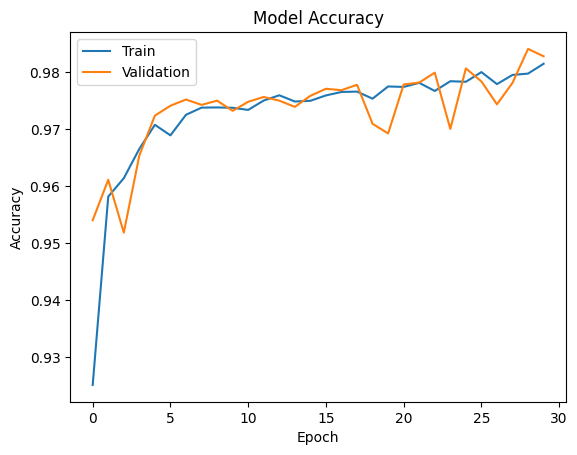

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = model.predict(X_test)


788/788 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step


In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)


AUC Score: 0.9981885365358525


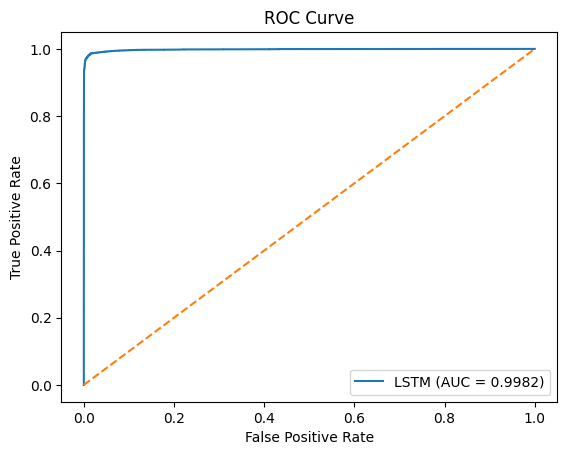

In [21]:
plt.figure()
plt.plot(fpr, tpr, label="LSTM (AUC = %0.4f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [ ]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))